# Classificação: Primeiros passos

Neste projeto, iremos analisar dados de uma campanha de marketing para aderência de investimentos. O intuito é usar as informações dos dados para prever se os clientes de um banco vão aplicar o dinheiro em um investimento ou não.

Essa previsão será feita utilizando machine learning e este notebook vai conter os passos para se obter um modelo capaz de realizar as previsões, desde a **leitura**, **análise exploratória**, **separação** e **transformação** dos dados, até o **ajuste**, **avaliação** e **comparação** de modelos de classificação.

In [ ]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import pickle

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier

# Análise exploratória

## Fazendo a leitura dos dados

Podemos realizar a leitura dos dados a partir da biblioteca `pandas`. Por conta disso, vamos realizar a importação da biblioteca com o comando `import pandas as pd`.

Como o arquivo de dados está no formato *csv*, vamos realizar a leitura com a função [`read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html).

In [ ]:
dados = pd.read_csv('https://cdn3.gnarususercontent.com.br/3067-classificacao/Projeto/dados/marketing_investimento.csv')
dados

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos,aderencia_investimento
0,45,casado (a),superior,nao,242,nao,587,1,sim
1,42,casado (a),medio,nao,1289,nao,250,4,sim
2,23,solteiro (a),superior,nao,363,nao,16,18,nao
3,58,divorciado (a),superior,nao,1382,nao,700,1,sim
4,50,casado (a),medio,nao,3357,nao,239,4,sim
...,...,...,...,...,...,...,...,...,...
1263,52,solteiro (a),superior,nao,83,nao,1223,6,sim
1264,35,solteiro (a),superior,nao,5958,nao,215,1,sim
1265,30,solteiro (a),superior,nao,-477,sim,1532,2,sim
1266,42,casado (a),superior,nao,2187,nao,525,3,sim


Para criar modelos de classificação, precisamos utilizar dados de qualidade, sem inconsistências e sem dados faltantes. Vamos checar se existem dados nulos e o tipo dos dados de cada coluna na base de dados a partir do método [`info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html).

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268 entries, 0 to 1267
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   idade                   1268 non-null   int64 
 1   estado_civil            1268 non-null   object
 2   escolaridade            1268 non-null   object
 3   inadimplencia           1268 non-null   object
 4   saldo                   1268 non-null   int64 
 5   fez_emprestimo          1268 non-null   object
 6   tempo_ult_contato       1268 non-null   int64 
 7   numero_contatos         1268 non-null   int64 
 8   aderencia_investimento  1268 non-null   object
dtypes: int64(4), object(5)
memory usage: 89.3+ KB


## Explorando os dados

Uma etapa muito importante em projetos de machine learning é a exploração e entendimento dos dados, conhecida como **análise exploratória**. Podemos utilizar gráficos para verificar quais são as informações em cada uma das colunas da base de dados, identificar inconsistências e padrões que possam existir.

Vamos explorar cada uma das colunas da base de dados com o uso da biblioteca `plotly`. Vamos começar pelas variáveis categóricas e depois explorar as variáveis numéricas.

### Variáveis categóricas

In [ ]:
px.histogram(dados, x='aderencia_investimento', text_auto=True)

In [ ]:
px.histogram(dados, x='estado_civil', text_auto=True, color='aderencia_investimento', barmode='group')

In [ ]:
px.histogram(dados, x='escolaridade', text_auto=True, color='aderencia_investimento', barmode='group')

In [ ]:
px.histogram(dados, x='inadimplencia', text_auto=True, color='aderencia_investimento', barmode='group')

In [ ]:
px.histogram(dados, x='fez_emprestimo', text_auto=True, color='aderencia_investimento', barmode='group')

### Variáveis numéricas

In [ ]:
px.box(dados, x='idade', color='aderencia_investimento')

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268 entries, 0 to 1267
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   idade                   1268 non-null   int64 
 1   estado_civil            1268 non-null   object
 2   escolaridade            1268 non-null   object
 3   inadimplencia           1268 non-null   object
 4   saldo                   1268 non-null   int64 
 5   fez_emprestimo          1268 non-null   object
 6   tempo_ult_contato       1268 non-null   int64 
 7   numero_contatos         1268 non-null   int64 
 8   aderencia_investimento  1268 non-null   object
dtypes: int64(4), object(5)
memory usage: 89.3+ KB


In [ ]:
px.box(dados, x='saldo', color='aderencia_investimento')

In [ ]:
px.box(dados, x='tempo_ult_contato', color='aderencia_investimento')

In [ ]:
px.box(dados, x='numero_contatos', color='aderencia_investimento')

# Transformação de dados

Para fazer a previsão dos valores com um modelo de machine learning, precisamos fazer a separação da variável alvo e variáveis explicativas. O y representa a variável que queremos prever, enquanto x representa todas as variáveis que serão utilizadas para explicar o comportamento de **y**.

## Variáveis explicativas e variável alvo

In [ ]:
x = dados.drop(columns=['aderencia_investimento'])
y = dados['aderencia_investimento']

In [ ]:
x

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos
0,45,casado (a),superior,nao,242,nao,587,1
1,42,casado (a),medio,nao,1289,nao,250,4
2,23,solteiro (a),superior,nao,363,nao,16,18
3,58,divorciado (a),superior,nao,1382,nao,700,1
4,50,casado (a),medio,nao,3357,nao,239,4
...,...,...,...,...,...,...,...,...
1263,52,solteiro (a),superior,nao,83,nao,1223,6
1264,35,solteiro (a),superior,nao,5958,nao,215,1
1265,30,solteiro (a),superior,nao,-477,sim,1532,2
1266,42,casado (a),superior,nao,2187,nao,525,3


In [ ]:
y

,aderencia_investimento
0,sim
1,sim
2,nao
3,sim
4,sim
...,...
1263,sim
1264,sim
1265,sim
1266,sim


## Transformando as variáveis explicativas

Os algoritmos de machine learning não compreendem dados no formato de texto, portanto devemos fazer transformações nos dados para o formato numérico para que o algoritmo consiga compreender as informações. Essa transformação precisa ser feita de forma que não altere a informação original do conjunto de dados, portanto não basta simplesmente alterar os valores para valores numéricos aleatórios.

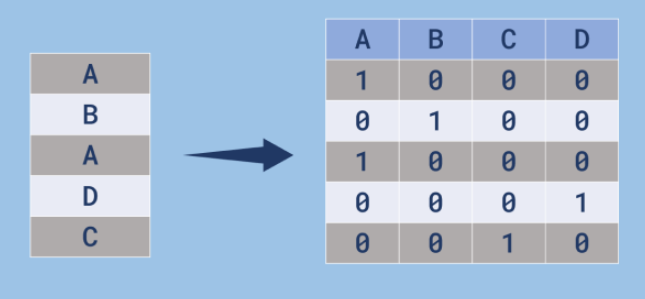

In [ ]:
colunas = x.columns

In [ ]:
one_hot = make_column_transformer(
    (OneHotEncoder(drop='if_binary'),
    ['estado_civil', 'escolaridade', 'inadimplencia', 'fez_emprestimo']),
    remainder='passthrough', sparse_threshold=0
)

In [ ]:
x = one_hot.fit_transform(x)

In [ ]:
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__estado_civil_casado (a)',
       'onehotencoder__estado_civil_divorciado (a)',
       'onehotencoder__estado_civil_solteiro (a)',
       'onehotencoder__escolaridade_fundamental',
       'onehotencoder__escolaridade_medio',
       'onehotencoder__escolaridade_superior',
       'onehotencoder__inadimplencia_sim',
       'onehotencoder__fez_emprestimo_sim', 'remainder__idade',
       'remainder__saldo', 'remainder__tempo_ult_contato',
       'remainder__numero_contatos'], dtype=object)

In [ ]:
pd.DataFrame(x, columns=one_hot.get_feature_names_out(colunas))

,onehotencoder__estado_civil_casado (a),onehotencoder__estado_civil_divorciado (a),onehotencoder__estado_civil_solteiro (a),onehotencoder__escolaridade_fundamental,onehotencoder__escolaridade_medio,onehotencoder__escolaridade_superior,onehotencoder__inadimplencia_sim,onehotencoder__fez_emprestimo_sim,remainder__idade,remainder__saldo,remainder__tempo_ult_contato,remainder__numero_contatos
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,45.0,242.0,587.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,42.0,1289.0,250.0,4.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,23.0,363.0,16.0,18.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,58.0,1382.0,700.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,50.0,3357.0,239.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1263,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,52.0,83.0,1223.0,6.0
1264,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,35.0,5958.0,215.0,1.0
1265,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,30.0,-477.0,1532.0,2.0
1266,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,42.0,2187.0,525.0,3.0


## Transformando a variável alvo

Assim como as variáveis explicativas, a variável alvo também precisa ser alterada para o formato numérico. Podemos representar uma variável alvo binária como 0 ou 1, onde 0 indica ausência da característica da variável e 1 representa a presença da característica.

In [ ]:
label_encoder = LabelEncoder()

In [ ]:
y = label_encoder.fit_transform(y)

In [ ]:
y

array([1, 1, 0, ..., 1, 1, 1])

# Seleção de modelos

Para compreender se o modelo está de fato aprendendo com os dados, precisamos fazer uma separação dos dados entre treinamento e teste. Os dados de treinamento são usados para ajustar o modelo, enquanto os dados de teste servem para verificar o aprendizado do modelo em dados que não foram utilizados no momento do ajuste.

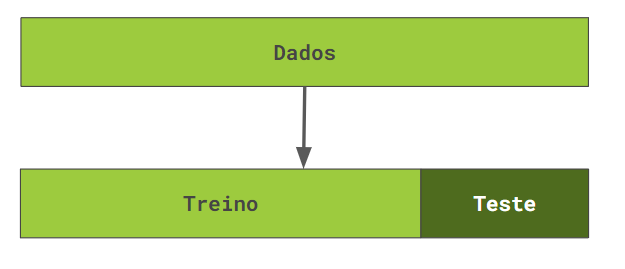

In [ ]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, stratify=y, random_state=5)

## Modelo base

O modelo mais simples de classificar os dados é simplesmente utilizar um algoritmo que chuta todas as classificações para a classe que tem maior frequência. Esse algoritmo serve como um critério de comparação, para identificar se os outros modelos tem um desempenho melhor do que a classificação mais simples possível.

In [ ]:
dummy = DummyClassifier()
dummy.fit(x_treino, y_treino)

dummy.score(x_teste, y_teste)

0.6025236593059937

## Árvore de decisão

O modelo de árvore de decisão é muito utilizado pela sua alta **explicabilidade** e **processamento rápido**, mantendo um desempenho bem interessante.

Ele se baseia em decisões simples tomadas pelo algoritmo, separando os dados com base em comparações de **menor** e **maior** nos valores das colunas da base de dados.

In [ ]:
arvore = DecisionTreeClassifier(random_state=5)
arvore.fit(x_treino, y_treino)

arvore.predict(x_teste)

arvore.score(x_teste, y_teste)

0.6656151419558359

In [ ]:
nome_colunas = ['casado (a)',
                'divorciado (a)',
                'solteiro (a)',
                'fundamental',
                'medio',
                'superior',
                'inadimplencia',
                'fez_emprestimo',
                'idade',
                'saldo',
                'tempo_ult_contato',
                'numero_contatos']

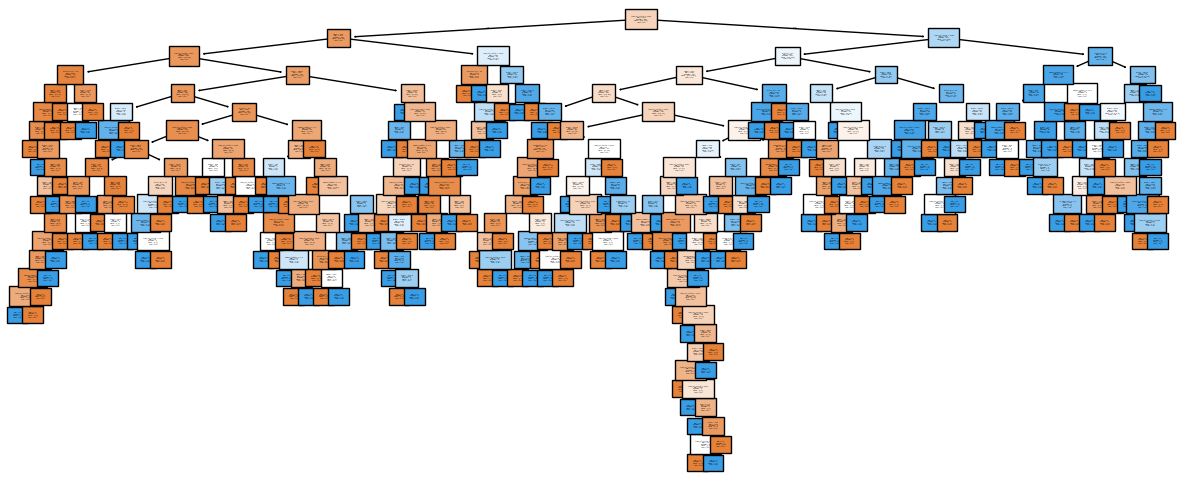

In [ ]:
plt.figure(figsize=(15, 6))
plot_tree(arvore, filled=True, class_names=['Não', 'Sim'], fontsize=1, feature_names=nome_colunas)
plt.show()

In [ ]:
arvore.score(x_treino, y_treino)

1.0

In [ ]:
arvore = DecisionTreeClassifier(max_depth=3, random_state=5)
arvore.fit(x_treino, y_treino)

arvore.score(x_treino, y_treino)

0.7613038906414301

In [ ]:
arvore.score(x_teste, y_teste)

0.7160883280757098

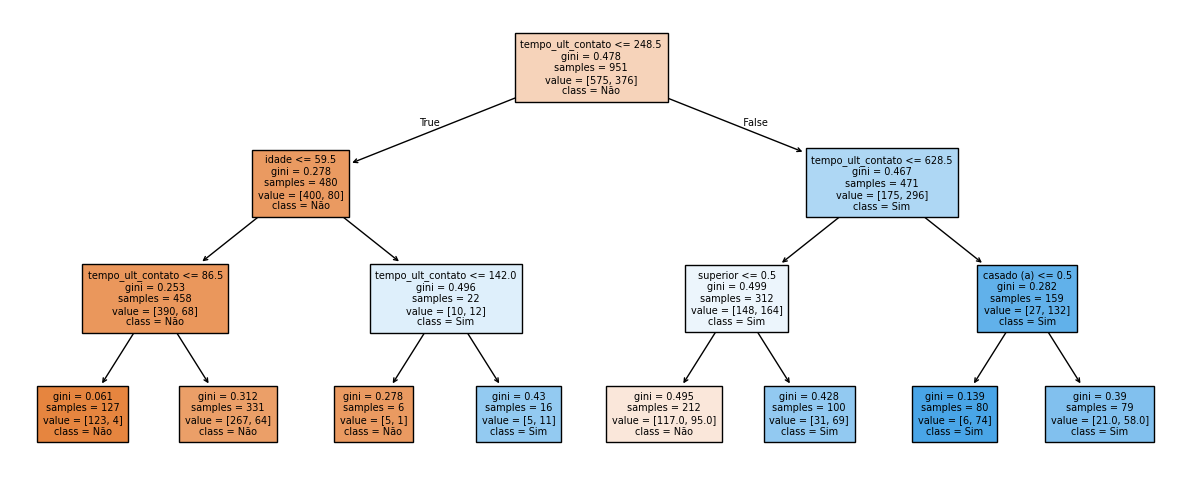

In [ ]:
plt.figure(figsize=(15, 6))
plot_tree(arvore, filled=True, class_names=['Não', 'Sim'], fontsize=7, feature_names=nome_colunas)
plt.show()

## KNN

O algoritmo KNN se baseia no cálculo de distância entre os registros da base de dados e busca elementos que estejam próximos uns dos outros (vizinhos) para tomar a decisão da classificação.

Por conta de usar cálculos de distância, esse algoritmo é influenciado pela escala das variáveis e por conta disso é necessário uma transformação nos dados antes de utilizar esse método.

Alguns algoritmos podem atribuir um peso maior aos valores das variáveis devido a escala dos valores e não pela importância da classificação da variável alvo. Por exemplo, em uma base de dados com a colunas **idade** e **salário**, o algoritmo pode dar um peso de decisão maior para os valores do salário simplesmente por estar em uma escala maior do que os valores de idade, e não porque a variável salário é mais importante do que a variável idade.

Nesses casos, precisamos fazer uma transformação nos dados para que fiquem em uma mesma escala, fazendo com que o algoritmo não seja influenciado incorretamente pelos valores numéricos divergentes entre as variáveis.

In [ ]:
# Normalizando os dados

normalizacao = MinMaxScaler()

x_treino_normalizado = normalizacao.fit_transform(x_treino)

In [ ]:
pd.DataFrame(x_treino_normalizado, columns=nome_colunas)

,casado (a),divorciado (a),solteiro (a),fundamental,medio,superior,inadimplencia,fez_emprestimo,idade,saldo,tempo_ult_contato,numero_contatos
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.205882,0.065564,0.123734,0.032258
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.147059,0.045792,0.396527,0.032258
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.338235,0.076036,0.335022,0.000000
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.573529,0.062866,0.315123,0.000000
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.338235,0.148380,0.065847,0.129032
...,...,...,...,...,...,...,...,...,...,...,...,...
946,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.191176,0.044265,0.246382,0.129032
947,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.205882,0.028043,0.275687,0.032258
948,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.323529,0.042952,0.024964,0.129032
949,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.176471,0.042810,0.023878,0.000000


In [ ]:
knn = KNeighborsClassifier()

knn.fit(x_treino_normalizado, y_treino)

KNeighborsClassifier()

In [ ]:
x_teste_normalizado = normalizacao.transform(x_teste)

knn.score(x_teste_normalizado, y_teste)

0.6876971608832808

# Escolhendo e salvando o melhor modelo

In [ ]:
print(f"Acurácia do Dummy: {dummy.score(x_teste, y_teste)}")
print(f"Acurácia da árvore de decisão: {arvore.score(x_teste, y_teste)}")
print(f"Acurácia do KNN: {knn.score(x_teste_normalizado, y_teste)}")

Acurácia do Dummy: 0.6025236593059937
Acurácia da árvore de decisão: 0.7160883280757098
Acurácia do KNN: 0.6876971608832808


In [ ]:
with open('modelo_onehotenc.pkl', 'wb') as arquivo:
  pickle.dump(one_hot, arquivo)

In [ ]:
with open('modelo_arvore.pkl', 'wb') as arquivo:
  pickle.dump(arvore, arquivo)

In [ ]:
dados.head()

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos,aderencia_investimento
0,45,casado (a),superior,nao,242,nao,587,1,sim
1,42,casado (a),medio,nao,1289,nao,250,4,sim
2,23,solteiro (a),superior,nao,363,nao,16,18,nao
3,58,divorciado (a),superior,nao,1382,nao,700,1,sim
4,50,casado (a),medio,nao,3357,nao,239,4,sim


In [ ]:
novo_dado = {
    'idade': [45],
    'estado_civil':['solteiro (a)'],
    'escolaridade':['superior'],
    'inadimplencia': ['nao'],
    'saldo': [23040],
    'fez_emprestimo': ['nao'],
    'tempo_ult_contato': [800],
    'numero_contatos': [4]
}

novo_dado = pd.DataFrame(novo_dado)
novo_dado

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos
0,45,solteiro (a),superior,nao,23040,nao,800,4


In [ ]:
modelo_onehotenc = pd.read_pickle('modelo_onehotenc.pkl')
modelo_arvore = pd.read_pickle('modelo_arvore.pkl')

In [ ]:
novo_dado = modelo_onehotenc.transform(novo_dado)

modelo_arvore.predict(novo_dado)

array([1])

# Desafio

O tema da base de dados é a de **churn** de clientes. O churn é uma métrica que indica os clientes que cancelam o serviço em determinado período de tempo.

## Análise exploratória

1. A primeira etapa em um projeto de Machine Learning é a obtenção de dados. A partir dessa obtenção, podemos fazer a leitura dos dados para se construir um modelo. Como tarefa inicial, faça a leitura da base de dados e verifique a presença de dados nulos. Além disso, remova a coluna 'id_cliente', uma vez que esse tipo de informação única para cada linha não é útil para uso em modelos de machine learning.

In [ ]:
dados_desafio = pd.read_csv('https://cdn3.gnarususercontent.com.br/3067-classificacao/Projeto/desafios/dados_desafios/churn.csv')
dados_desafio

,id_cliente,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,15634602,619,França,Mulher,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,França,Mulher,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,França,Mulher,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,França,Homem,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,França,Homem,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,França,Mulher,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Alemanha,Homem,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
dados_desafio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_cliente           10000 non-null  int64  
 1   score_credito        10000 non-null  int64  
 2   pais                 10000 non-null  object 
 3   sexo_biologico       10000 non-null  object 
 4   idade                10000 non-null  int64  
 5   anos_de_cliente      10000 non-null  int64  
 6   saldo                10000 non-null  float64
 7   servicos_adquiridos  10000 non-null  int64  
 8   tem_cartao_credito   10000 non-null  int64  
 9   membro_ativo         10000 non-null  int64  
 10  salario_estimado     10000 non-null  float64
 11  churn                10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [ ]:
dados_desafio.drop(columns=['id_cliente'], inplace=True)

dados_desafio.head()

,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,619,França,Mulher,42,2,0.00,1,1,1,101348.88,1
1,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58,0
2,502,França,Mulher,42,8,159660.80,3,1,0,113931.57,1
3,699,França,Mulher,39,1,0.00,2,0,0,93826.63,0
4,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
dados.columns

RangeIndex(start=0, stop=1268, step=1)

2. Após a leitura dos dados, é importante conhecer os dados, checando inconsistências e entendendo o comportamento de cada uma das colunas. Nesta tarefa, faça uma análise exploratória utilizando gráficos para as **variáveis categóricas** da base de dados, incluindo a variável alvo churn. Para essas variáveis, pode ser utilizado gráficos de barras para fazer a contagem das categorias e fazer um agrupamento por cores de acordo com as categorias da variável alvo.

In [ ]:
px.histogram(dados_desafio, x='churn', text_auto=True)

In [ ]:
px.histogram(dados_desafio, x='pais', text_auto=True, color='churn', barmode='group')

In [ ]:
px.histogram(dados_desafio, x='sexo_biologico', text_auto=True, color='churn', barmode='group')

In [ ]:
px.histogram(dados_desafio, x='servicos_adquiridos', text_auto=True, color='churn', barmode='group')

In [ ]:
px.histogram(dados_desafio, x='tem_cartao_credito', text_auto=True, color='churn', barmode='group')

In [ ]:
px.histogram(dados_desafio, x='membro_ativo', text_auto=True, color='churn', barmode='group')

3. Depois de explorar as *variáveis categóricas*, chegou a vez das variáveis numéricas. Construa gráficos de distribuição como boxplots ou histogramas para analisar o comportamento dos valores numéricos e checar se existem valores inconsistentes.\

In [ ]:
px.box(dados_desafio, x='score_credito', color='churn')

In [ ]:
px.box(dados_desafio, x='idade', color='churn')

In [ ]:
px.box(dados_desafio, x='anos_de_cliente', color='churn')

In [ ]:
px.box(dados_desafio, x='saldo', color='churn')

In [ ]:
px.box(dados_desafio, x='salario_estimado', color='churn')

## Transformação de dados

1. Para utilizar os dados nos algoritmos de Machine Learning, precisamos informar quais são as variáveis explicativas e qual é a variável alvo. Neste desafio, faça a separação da base de dados de churn entre as variáveis explicativas, armazenando em uma variável x e a variável alvo em y.

In [ ]:
x_desafio = dados_desafio.drop(columns=['churn'])
y_desafio = dados_desafio['churn']

2. Variáveis categóricas que estejam em formato de texto não podem ser utilizadas diretamente nos modelos de Machine Learning. Neste desafio, faça a transformação das variáveis categóricas para o formato numérico usando o OneHotEncoder, utilizando o parâmetro drop='if_binary' caso alguma variável tenha apenas 2 categorias.

In [ ]:
one_hot_desafio = make_column_transformer(
    (OneHotEncoder(drop='if_binary'),
    ['pais', 'sexo_biologico', 'servicos_adquiridos', 'tem_cartao_credito', 'membro_ativo']),
    remainder='passthrough', sparse_threshold=0
)

In [ ]:
colunas_desafio = x_desafio.columns

x_desafio = one_hot_desafio.fit_transform(x_desafio)

one_hot_desafio.get_feature_names_out(colunas_desafio)

array(['onehotencoder__pais_Alemanha', 'onehotencoder__pais_Espanha',
       'onehotencoder__pais_França',
       'onehotencoder__sexo_biologico_Mulher',
       'onehotencoder__servicos_adquiridos_1',
       'onehotencoder__servicos_adquiridos_2',
       'onehotencoder__servicos_adquiridos_3',
       'onehotencoder__servicos_adquiridos_4',
       'onehotencoder__tem_cartao_credito_1',
       'onehotencoder__membro_ativo_1', 'remainder__score_credito',
       'remainder__idade', 'remainder__anos_de_cliente',
       'remainder__saldo', 'remainder__salario_estimado'], dtype=object)

In [ ]:
pd.DataFrame(x_desafio, columns=one_hot_desafio.get_feature_names_out(colunas_desafio))

,onehotencoder__pais_Alemanha,onehotencoder__pais_Espanha,onehotencoder__pais_França,onehotencoder__sexo_biologico_Mulher,onehotencoder__servicos_adquiridos_1,onehotencoder__servicos_adquiridos_2,onehotencoder__servicos_adquiridos_3,onehotencoder__servicos_adquiridos_4,onehotencoder__tem_cartao_credito_1,onehotencoder__membro_ativo_1,remainder__score_credito,remainder__idade,remainder__anos_de_cliente,remainder__saldo,remainder__salario_estimado
0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,619.0,42.0,2.0,0.00,101348.88
1,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,608.0,41.0,1.0,83807.86,112542.58
2,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,502.0,42.0,8.0,159660.80,113931.57
3,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,699.0,39.0,1.0,0.00,93826.63
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,850.0,43.0,2.0,125510.82,79084.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,771.0,39.0,5.0,0.00,96270.64
9996,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,516.0,35.0,10.0,57369.61,101699.77
9997,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,709.0,36.0,7.0,0.00,42085.58
9998,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,772.0,42.0,3.0,75075.31,92888.52


3. A variável alvo, como é do tipo categórica, também precisa passar por um tratamento similar às variáveis explicativas categóricas para que possa ser usada nos algoritmos. Nessa tarefa, utilize o método LabelEncoder para fazer a transformação da variável churn.

In [ ]:
y_desafio.unique()

array([1, 0])

In [ ]:
y_desafio.info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: churn
Non-Null Count  Dtype
--------------  -----
10000 non-null  int64
dtypes: int64(1)
memory usage: 78.3 KB


In [ ]:
# Caso seja necessário a transformação da variável alvo

label_encoder_desafio = LabelEncoder()

y_desafio = label_encoder_desafio.fit_transform(y_desafio)

## Ajustando modelos

1. A separação dos dados entre conjunto de treinamento e teste é essencial para compreender se um modelo está conseguindo aprender os padrões e generalizar para novos dados. Nesta tarefa, faça a divisão da base de dados entre treinamento e teste de forma estratificada.

In [ ]:
x_treino_desafio, x_teste_desafio, y_treino_desafio, y_teste_desafio = train_test_split(x_desafio, y_desafio, stratify=y_desafio, random_state=5)

2. Um modelo de base é muito importante para definir um critério de comparação para modelos mais complexos. Nesta etapa, crie um modelo de base com o DummyClassifier e encontre a taxa de acerto com o método score.

In [ ]:
dummy_desafio = DummyClassifier()
dummy_desafio.fit(x_treino_desafio, y_treino_desafio)

dummy_desafio.score(x_teste_desafio, y_teste_desafio)

0.7964

3. A árvore de decisão é um algoritmo que faz as classificações a partir de decisões simples tomadas a partir dos dados. Temos que tomar certo cuidado para não utilizar uma profundidade muito grande, porque isso pode provocar um sobreajuste do modelo aos dados de treinamento. Neste desafio, crie um modelo de árvore de decisão com o parâmetro max_depth=4, avalie o desempenho do modelo nos dados de teste e visualize as decisões da árvore usando o método plot_tree.

In [ ]:
arvore_desafio = DecisionTreeClassifier(max_depth=4, random_state=5)
arvore_desafio.fit(x_treino_desafio, y_treino_desafio)

arvore_desafio.score(x_treino_desafio, y_treino_desafio)

0.8529333333333333

In [ ]:
arvore_desafio.score(x_teste_desafio, y_teste_desafio)

0.8508

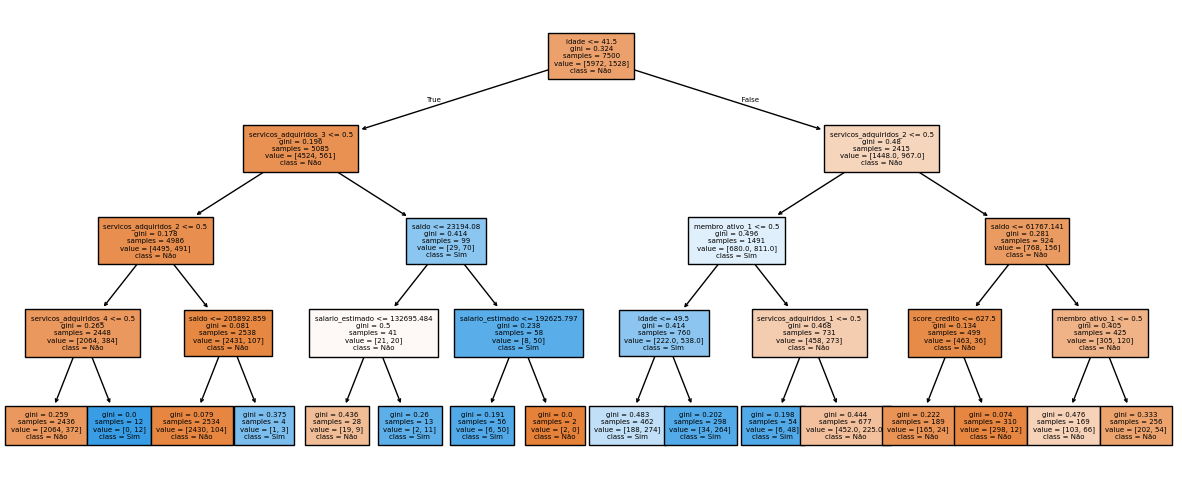

In [ ]:
feature_names = [name.replace('onehotencoder__', '').replace('remainder__', '') for name in one_hot_desafio.get_feature_names_out(colunas_desafio)]

plt.figure(figsize=(15, 6))
plot_tree(arvore_desafio, filled=True, class_names=['Não', 'Sim'], fontsize= 5,
          feature_names=feature_names);

## Seleção de modelos

1. A normalização de dados é uma tarefa importante para manter todos os valores numéricos em uma mesma escala e garantir que todas as características tenham o mesmo impacto no modelo. Nesta tarefa, faça a normalização da base de dados usando o MinMaxScaler.

In [ ]:
normalizacao_desafio = MinMaxScaler()

x_treino_normalizado_desafio = normalizacao_desafio.fit_transform(x_treino_desafio)

In [ ]:
pd.DataFrame(x_treino_normalizado_desafio, columns=feature_names)

,pais_Alemanha,pais_Espanha,pais_França,sexo_biologico_Mulher,servicos_adquiridos_1,servicos_adquiridos_2,servicos_adquiridos_3,servicos_adquiridos_4,tem_cartao_credito_1,membro_ativo_1,score_credito,idade,anos_de_cliente,saldo,salario_estimado
0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.796,0.216216,0.8,0.000000,0.267600
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.612,0.256757,0.2,0.000000,0.338919
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.634,0.256757,0.5,0.386645,0.890516
3,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.514,0.040541,0.0,0.000000,0.580365
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.374,0.270270,0.6,0.594774,0.738898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.590,0.391892,0.9,0.637940,0.609048
7496,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.676,0.229730,0.6,0.000000,0.127054
7497,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.646,0.229730,0.6,0.000000,0.492884
7498,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.720,0.202703,0.2,0.000000,0.364454


2. Com os dados normalizados, podemos utilizar o modelo KNN, que faz cálculos de distância para encontrar os vizinhos mais próximos. Nesta atividade, crie um modelo KNN usando o KNeighborsClassifier com os dados normalizados e avalie o desempenho nos dados de teste, também normalizados.

In [ ]:
knn_desafio = KNeighborsClassifier()

knn_desafio.fit(x_treino_normalizado_desafio, y_treino_desafio)

KNeighborsClassifier()

In [ ]:
x_teste_normalizado_desafio = normalizacao_desafio.transform(x_teste_desafio)

knn_desafio.score(x_teste_normalizado_desafio, y_teste_desafio)

0.8288

3. Após a construção dos modelos, é o momento de comparar os resultados e selecionar aquele que tem o melhor desempenho. Neste desafio, avalie a taxa de acerto dos modelos DummyClassifier, DecisionTreeClassifier e KNeighborsClassifier que foram construídos nos outros desafios utilizando o método score e, em seguida, armazene o modelo com melhor acurácia em um arquivo pickle. Os modelos de transformação também precisam ser armazenados, que é o caso do OneHotEncoder e do MinMaxScaler, caso o KNN tenha o melhor desempenho.

In [ ]:
print(f"Acurácia do Dummy: {dummy_desafio.score(x_teste_desafio, y_teste_desafio)}")
print(f"Acurácia da árvore de decisão: {arvore_desafio.score(x_teste_desafio, y_teste_desafio)}")
print(f"Acurácia do KNN: {knn_desafio.score(x_teste_normalizado_desafio, y_teste_desafio)}")

Acurácia do Dummy: 0.7964
Acurácia da árvore de decisão: 0.8508
Acurácia do KNN: 0.8288


In [ ]:
with open('modelo_onehotenc_desafio.pkl', 'wb') as arquivo:
  pickle.dump(one_hot_desafio, arquivo)

with open('modelo_arvore_desafio.pkl', 'wb') as arquivo:
  pickle.dump(arvore_desafio, arquivo)

4. Depois que o modelo está em produção, já pode ser utilizado para classificar novos dados. Neste desafio, faça a leitura dos arquivos pickle dos modelos que foram salvos no desafio anterior e utilize os modelos para fazer a predição do seguinte registro:

In [ ]:
novo_dado_desafio = pd.DataFrame({
    'score_credito': [850],
    'pais':['França'],
    'sexo_biologico':['Homem'],
    'idade': [27],
    'anos_de_cliente': [3],
    'saldo': [56000],
    'servicos_adquiridos': [1],
    'tem_cartao_credito': [1],
    'membro_ativo': [1],
    'salario_estimado': [85270.00]
})

novo_dado_desafio

,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado
0,850,França,Homem,27,3,56000,1,1,1,85270.0


In [ ]:
modelo_onehotenc_desafio = pickle.load(open('modelo_onehotenc_desafio.pkl', 'rb'))
modelo_arvore_desafio = pd.read_pickle('modelo_arvore_desafio.pkl')

In [ ]:
novo_dado_desafio = modelo_onehotenc_desafio.transform(novo_dado_desafio)

modelo_arvore_desafio.predict(novo_dado_desafio)

array([0])